# 02 · Attention Matrices as Features for Sentiment Classification

Can the **attention patterns** of a language model, without its hidden states, tell a positive review from a negative one?

For every review we run a forward pass with `output_attentions=True`, compress each attention head into a few statistics, and train classic classifiers on the resulting vectors.

| Model | Architecture | Layers × heads |
|---|---|---|
| `dbmdz/bert-base-turkish-cased` | Encoder | 12 × 12 |
| `ytu-ce-cosmos/Turkish-Gemma-9b-v0.1` | Decoder | 42 × 16 |

| Feature set | Per head | Vector size (BERT / Gemma) |
|---|---|---|
| Diagonal mean | mean of the attention diagonal ("how much does each token attend to itself?") | 144 / 672 |
| Rich statistics | diagonal mean, mean, max, std | 576 / 2,688 |
| [CLS] / first-token | mean attention of the first token's row | 144 / 672 |

> Feature extraction for Gemma-9B requires a GPU (~30 min per feature set on 10K reviews). Generated `.npy` feature files are not included in the repo; run the extraction cells to recreate them.

## 1. BERT · Diagonal-mean features

In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

# Load model and tokenizer
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

# Feature extractor with logging
def extract_attention_features(text, max_length=128, verbose=False):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = model(**inputs)
    attentions = outputs.attentions  # layer x batch x head x from x to

    features = []
    for layer_idx, layer_attention in enumerate(attentions):
        layer_attention = layer_attention[0]  # remove batch
        for head_idx, head_attention in enumerate(layer_attention):
            diag = torch.diagonal(head_attention, dim1=-2, dim2=-1)
            mean_val = diag.mean().item()
            features.append(mean_val)
            if verbose and layer_idx == 0:
                print(f"Layer {layer_idx}, Head {head_idx}: {mean_val:.4f}")
    return features

In [10]:
# 1. CSV'den oku
df = pd.read_csv("../data/balanced_movie_reviews.csv")

# 2. Get comments and labels
comments = df["comment"].tolist()
labels = df["class"].tolist()

# 3. Feature extraction (with progress bar)
X = [extract_attention_features(comment) for comment in tqdm(comments)]
y = labels

# 4. Save as NumPy
np.save("X_attention_features.npy", X)
np.save("y_labels.npy", y)


In [11]:
import numpy as np
import pandas as pd

X = np.load("X_attention_features.npy")
y = np.load("y_labels.npy")

df_feat = pd.DataFrame(X)
df_feat["label"] = y
df_feat.to_csv("attention_features.csv", index=False)


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # → should print cuda


cuda


### Train/test split and baseline classifiers

In [13]:
import numpy as np

X = np.load("X_attention_features.npy")
y = np.load("y_labels.npy")

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [20]:
print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

🎯 Accuracy: 0.632

📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.61      0.63      1000
         1.0       0.63      0.65      0.64      1000

    accuracy                           0.63      2000
   macro avg       0.63      0.63      0.63      2000
weighted avg       0.63      0.63      0.63      2000


🧩 Confusion Matrix:
 [[615 385]
 [351 649]]


In [23]:
from sklearn.ensemble import RandomForestClassifier

clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2.fit(X_train, y_train)
y_pred = clf2.predict(X_test)

In [24]:
print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

🎯 Accuracy: 0.637

📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.67      0.65      1000
         1.0       0.65      0.61      0.63      1000

    accuracy                           0.64      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.64      0.64      0.64      2000


🧩 Confusion Matrix:
 [[667 333]
 [393 607]]


In [25]:
from sklearn.svm import SVC

clf3 = SVC(kernel="linear", C=1.0, random_state=42)
clf3.fit(X_train, y_train)
y_pred = clf3.predict(X_test)


In [26]:
print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

🎯 Accuracy: 0.637

📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.63      0.63      1000
         1.0       0.63      0.65      0.64      1000

    accuracy                           0.64      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.64      0.64      0.64      2000


🧩 Confusion Matrix:
 [[626 374]
 [352 648]]


## 2. BERT · Rich attention statistics

In [23]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

# Load model and tokenizer
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)  # Move model to GPU

def extract_rich_attention_features(text, max_length=128, verbose=False):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}  # Move input tensors to GPU
    with torch.no_grad():
        outputs = model(**inputs)
    attentions = outputs.attentions  # layer x batch x head x from x to

    features = []
    for layer_idx, layer_attention in enumerate(attentions):
        layer_attention = layer_attention[0]  # remove batch dim (batch=1)
        for head_idx, head_attention in enumerate(layer_attention):
            diag = torch.diagonal(head_attention, dim1=-2, dim2=-1)
            diag_mean = diag.mean().item()
            mean_all = head_attention.mean().item()
            max_all = head_attention.max().item()
            std_all = head_attention.std().item()
            
            features.extend([diag_mean, mean_all, max_all, std_all])

            if verbose and layer_idx == 0:
                print(f"Layer {layer_idx}, Head {head_idx}: diag_mean={diag_mean:.4f}, mean_all={mean_all:.4f}, max_all={max_all:.4f}, std_all={std_all:.4f}")

    return features

In [2]:
df = pd.read_csv("../data/balanced_movie_reviews.csv")

# 2. Get comments and labels
comments = df["comment"].tolist()
labels = df["class"].tolist()

X_new = [extract_rich_attention_features(comment) for comment in tqdm(comments)]
np.save("X_attention_features_rich.npy", X_new)
#np.save("y_labels.npy", y)  # labels are unchanged, no need to save again


In [5]:
import numpy as np

X = np.load("X_attention_features_rich.npy")
y = np.load("y_labels.npy")

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()


--- Random Forest ---
Accuracy: 0.67
              precision    recall  f1-score   support

         0.0       0.66      0.70      0.68      1000
         1.0       0.68      0.64      0.66      1000

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000


--- Logistic Regression ---
Accuracy: 0.682
              precision    recall  f1-score   support

         0.0       0.68      0.68      0.68      1000
         1.0       0.68      0.68      0.68      1000

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000


--- SVC ---
Accuracy: 0.6565
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66      1000
         1.0       0.66      0.66      0.66      1000

    accuracy                           0.66      2000
   macro avg    

## 3. Class separability
Cosine similarity between attention-feature vectors of same-class vs. different-class review pairs.

In [8]:
import numpy as np

X = np.load("X_attention_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine_sim(vec1, vec2):
    return cosine_similarity([vec1], [vec2])[0][0]


In [10]:
import random

def sample_pairs(X, y, n_samples=1000):
    same_class_sims = []
    diff_class_sims = []

    # Group indices by class
    class0_indices = np.where(y == 0)[0]
    class1_indices = np.where(y == 1)[0]

    # Same-class pairs
    for _ in range(n_samples//2):
        i, j = random.sample(list(class0_indices), 2)
        same_class_sims.append(cosine_sim(X[i], X[j]))
    for _ in range(n_samples//2):
        i, j = random.sample(list(class1_indices), 2)
        same_class_sims.append(cosine_sim(X[i], X[j]))

    # Different-class pairs
    for _ in range(n_samples):
        i = random.choice(class0_indices)
        j = random.choice(class1_indices)
        diff_class_sims.append(cosine_sim(X[i], X[j]))

    return same_class_sims, diff_class_sims


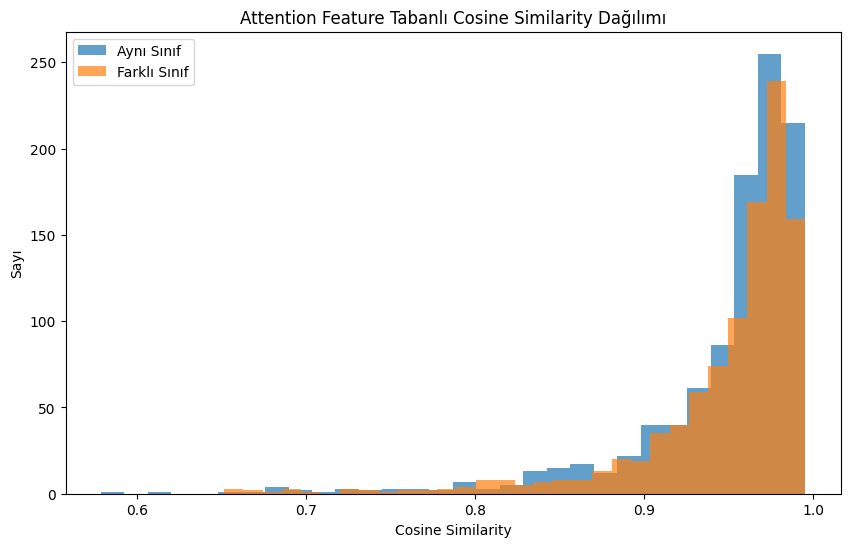

In [13]:
import matplotlib.pyplot as plt

same_sims, diff_sims = sample_pairs(X, y, n_samples=1000)

plt.figure(figsize=(10,6))
plt.hist(same_sims, bins=30, alpha=0.7, label="Aynı Sınıf")
plt.hist(diff_sims, bins=30, alpha=0.7, label="Farklı Sınıf")
plt.title("Attention Feature Tabanlı Cosine Similarity Dağılımı")
plt.xlabel("Cosine Similarity")
plt.ylabel("Sayı")
plt.legend()
plt.show()


## 4. Attention heatmaps for example reviews
Diagonal-mean value of each of the 144 heads (layer × head) for a single review.

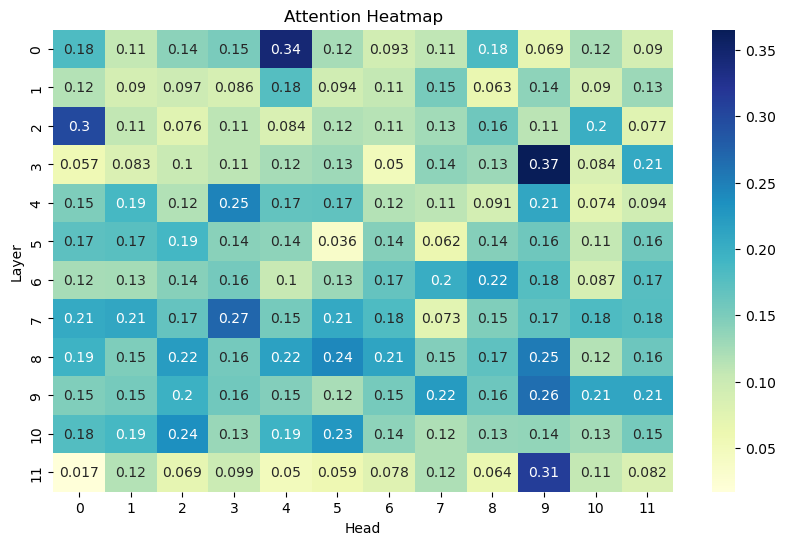

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_attention_heatmap(attention_features, title="Attention Heatmap"):
    num_layers = 12
    num_heads = 12
    data = np.array(attention_features).reshape((num_layers, num_heads))
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.show()

# Plot for an example review
plot_attention_heatmap(extract_attention_features("film çok güzeldi ve çok duygulandım"))


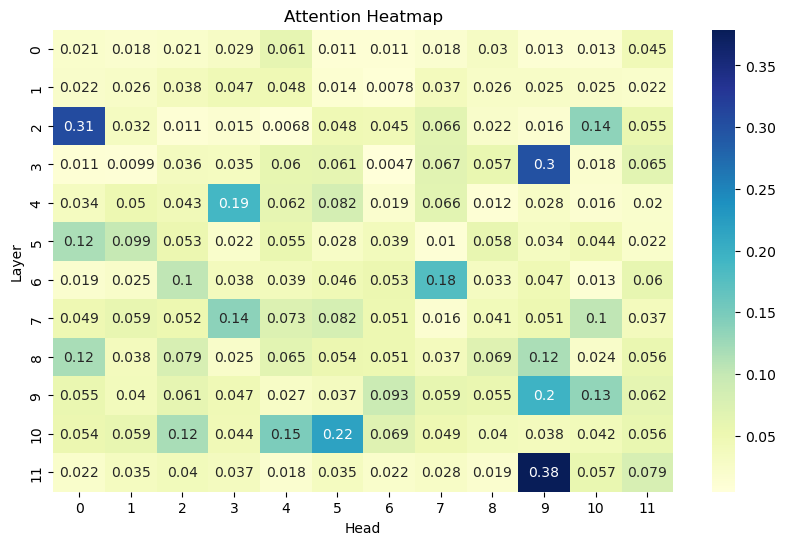

In [9]:
plot_attention_heatmap(extract_attention_features("bu tür senaryolara sahip çok film var ama bütün komedi filmlerin arasında en çok güldüren genelde bu türler. o yüzden böyle bi filmi izlerken hiç ön yargıyla izlemiyorum :)) çok güldüm çok eğlendim. chad michael murray uzun saçlı çok garipti olmuştu ;) herkese tavsiye ederim."))


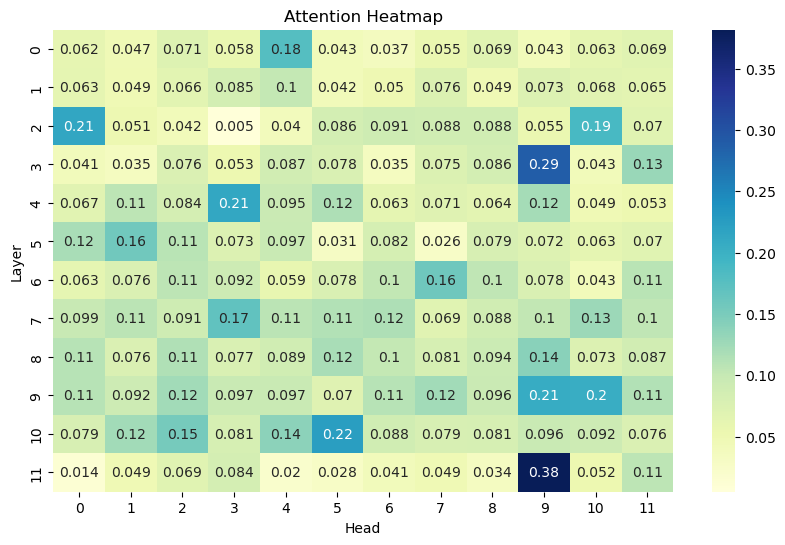

In [11]:
plot_attention_heatmap(extract_attention_features(" film hiç sürükleyici değildi bence. Yani adına yaraşır bir film değil."))


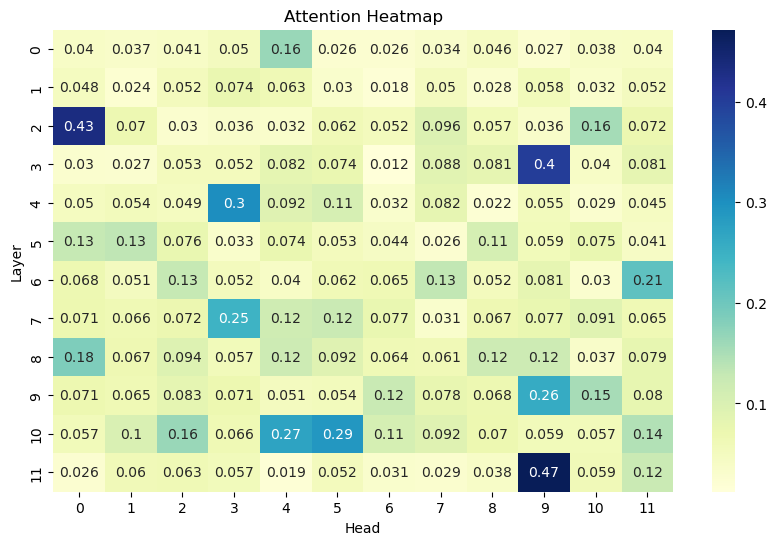

In [13]:
plot_attention_heatmap(extract_attention_features("Film Çok çok Basarılı Onun hayrınından Öteyim Onunla koınusmak için neler yapmazdım Kadri keskin    batman"))


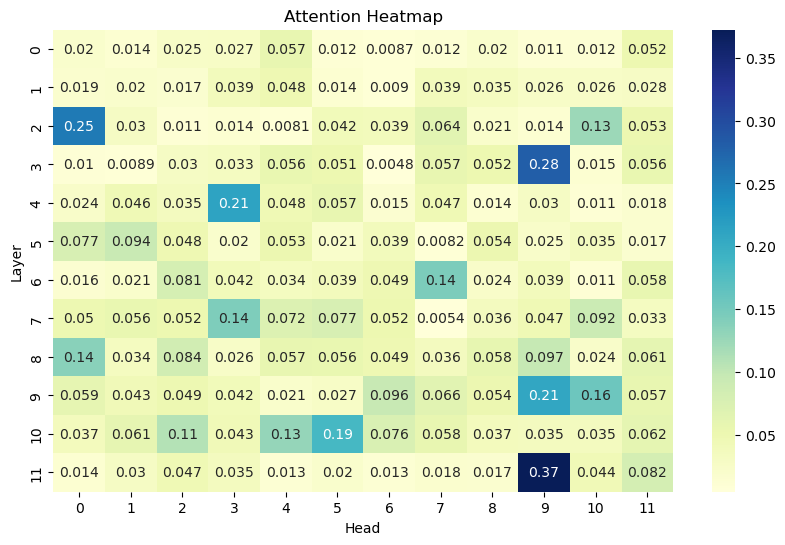

In [19]:
plot_attention_heatmap(extract_attention_features("Kötü bir film.. aksiyon bekleyenler, o tarz sevenler hoşlanmaz bu filmden şeklinde yorumlar yazılmış ama ben dram seven biri olarak bu filmi hiç beğenmedim... filmin ilk 10 dakikası güzeldi ama devamı ne yazıkki olmamış.. süresi uzun olmamasına rağmen son derece sıkıcı bir film.. ve en önemlisi de etkileyici değil.. 3/10"))    

## 5. BERT · [CLS]-token attention features

In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

# Load model and tokenizer
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Attention extractor focusing on the [CLS] token
def extract_cls_attention_features(text, max_length=128, verbose=False):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions  # shape: (num_layers, batch, num_heads, seq_len, seq_len)
    cls_attentions = []

    for layer_idx, layer_attention in enumerate(attentions):
        # shape: (batch=1, num_heads, seq_len, seq_len)
        layer_attention = layer_attention[0]  # Remove batch dim
        for head_idx, head_attention in enumerate(layer_attention):
            # [CLS] token is usually at index 0
            cls_weights = head_attention[0]  # shape: (seq_len,)
            mean_cls_attention = cls_weights.mean().item()
            cls_attentions.append(mean_cls_attention)
            if verbose and layer_idx == 0:
                print(f"Layer {layer_idx}, Head {head_idx}: CLS mean attention = {mean_cls_attention:.4f}")

    return cls_attentions


In [8]:
# Read data from CSV
df = pd.read_csv("../data/balanced_movie_reviews.csv")
comments = df["comment"].tolist()
labels = df["class"].tolist()

# Feature extraction
X_cls = [extract_cls_attention_features(comment) for comment in tqdm(comments)]
y = labels

# Save as NumPy file
np.save("X_cls_attention_features.npy", X_cls)
np.save("y_labels.npy", y)

print("✅ [CLS] attention features extracted and saved.")


✅ [CLS] attention features extracted and saved.


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load data
X = np.load("X_cls_attention_features.npy")
y = np.load("y_labels.npy")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Try models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(kernel="linear", random_state=42)
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"--- {name} ---")
    print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
    print("📋 Classification Report:\n", classification_report(y_test, y_pred))
    print()


--- Random Forest ---
🎯 Accuracy: 0.491
📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.49      0.52      0.51      1000
         1.0       0.49      0.46      0.47      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000


--- Logistic Regression ---
🎯 Accuracy: 0.5
📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.50      1.00      0.67      1000
         1.0       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000




--- SVC ---
🎯 Accuracy: 0.5
📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1000
         1.0       0.50      1.00      0.67      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000




## 6. Comparison of all BERT feature sets
Same split (`random_state=42`) for every feature set; evaluated with 6 classifiers.


🔍 Diagonal Mean Features
✅ Accuracy: 0.6350
              precision    recall  f1-score   support

         0.0     0.6439    0.6249    0.6343      1013
         1.0     0.6264    0.6454    0.6357       987

    accuracy                         0.6350      2000
   macro avg     0.6351    0.6351    0.6350      2000
weighted avg     0.6353    0.6350    0.6350      2000



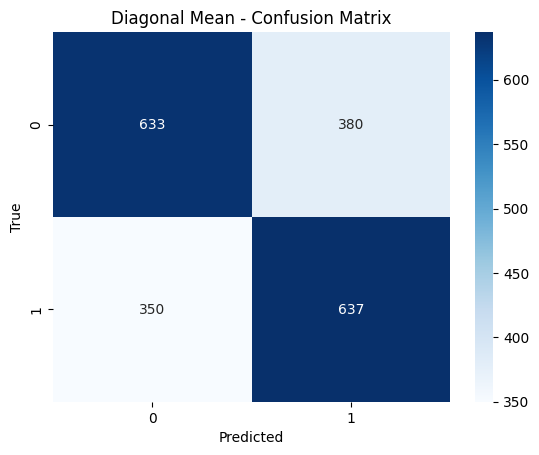


🔍 Rich Stats Features
✅ Accuracy: 0.6985
              precision    recall  f1-score   support

         0.0     0.6975    0.7147    0.7060      1013
         1.0     0.6996    0.6819    0.6906       987

    accuracy                         0.6985      2000
   macro avg     0.6985    0.6983    0.6983      2000
weighted avg     0.6985    0.6985    0.6984      2000



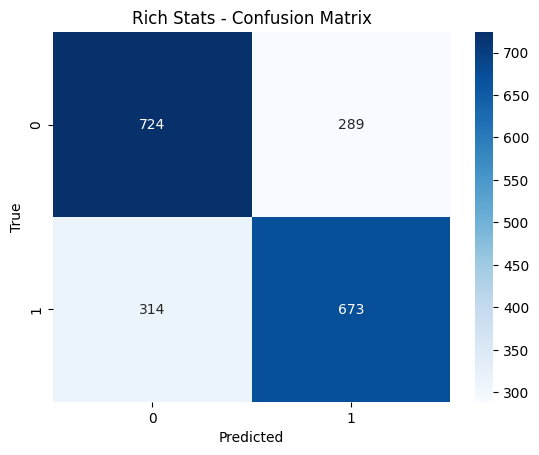


🔍 [CLS] Focus Features
✅ Accuracy: 0.5130
              precision    recall  f1-score   support

         0.0     0.5186    0.5360    0.5272      1013
         1.0     0.5068    0.4894    0.4979       987

    accuracy                         0.5130      2000
   macro avg     0.5127    0.5127    0.5126      2000
weighted avg     0.5128    0.5130    0.5128      2000



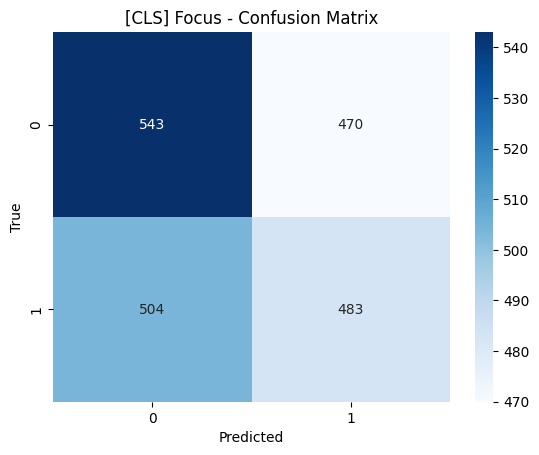

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load
y = np.load("y_labels.npy")

feature_sets = {
    "Diagonal Mean": np.load("X_attention_features.npy"),
    "Rich Stats": np.load("X_attention_features_rich.npy"),
    "[CLS] Focus": np.load("X_cls_attention_features.npy")
}

for name, X in feature_sets.items():
    print(f"\n🔍 {name} Features")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Simple model
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # Predictions and scores
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()



=== 🔍 Feature Set: Diagonal Mean ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.6480
              precision    recall  f1-score   support

         0.0     0.6649    0.6150    0.6390      1013
         1.0     0.6331    0.6819    0.6566       987

    accuracy                         0.6480      2000
   macro avg     0.6490    0.6484    0.6478      2000
weighted avg     0.6492    0.6480    0.6477      2000



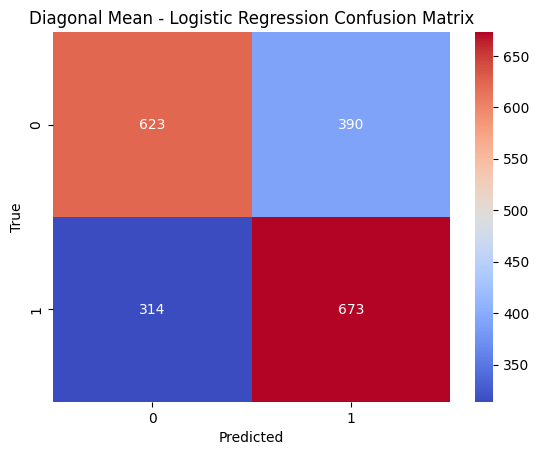


🚀 Model: SVC
✅ Accuracy: 0.6630
              precision    recall  f1-score   support

         0.0     0.6735    0.6496    0.6613      1013
         1.0     0.6530    0.6768    0.6647       987

    accuracy                         0.6630      2000
   macro avg     0.6632    0.6632    0.6630      2000
weighted avg     0.6634    0.6630    0.6630      2000



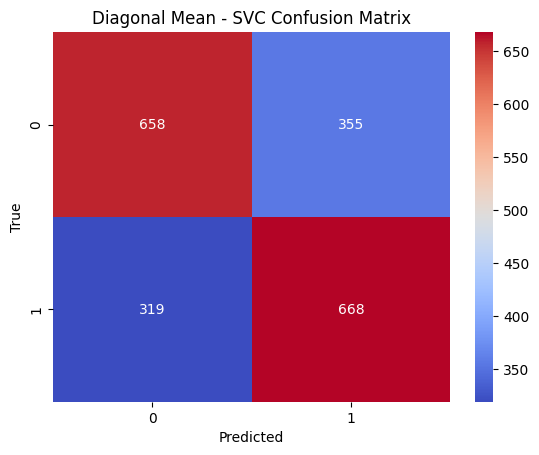


🚀 Model: KNN
✅ Accuracy: 0.5730
              precision    recall  f1-score   support

         0.0     0.5809    0.5637    0.5721      1013
         1.0     0.5654    0.5826    0.5739       987

    accuracy                         0.5730      2000
   macro avg     0.5731    0.5731    0.5730      2000
weighted avg     0.5732    0.5730    0.5730      2000



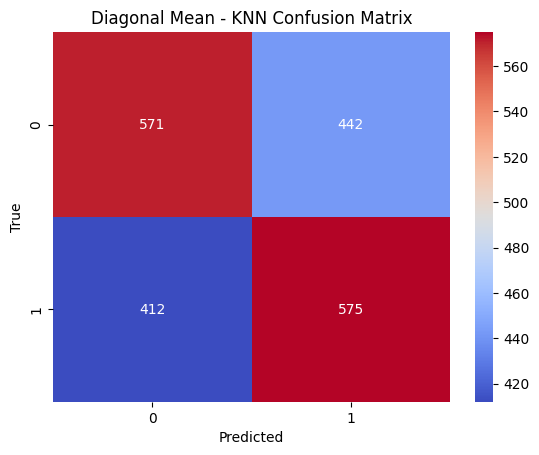


🚀 Model: Random Forest
✅ Accuracy: 0.6350
              precision    recall  f1-score   support

         0.0     0.6439    0.6249    0.6343      1013
         1.0     0.6264    0.6454    0.6357       987

    accuracy                         0.6350      2000
   macro avg     0.6351    0.6351    0.6350      2000
weighted avg     0.6353    0.6350    0.6350      2000



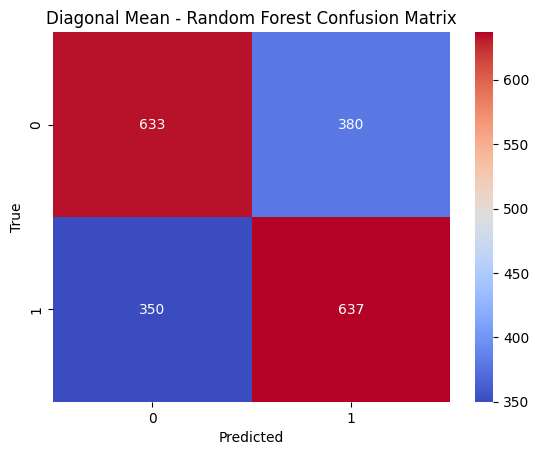


🚀 Model: Gradient Boosting
✅ Accuracy: 0.6320
              precision    recall  f1-score   support

         0.0     0.6375    0.6338    0.6356      1013
         1.0     0.6264    0.6302    0.6283       987

    accuracy                         0.6320      2000
   macro avg     0.6320    0.6320    0.6320      2000
weighted avg     0.6320    0.6320    0.6320      2000



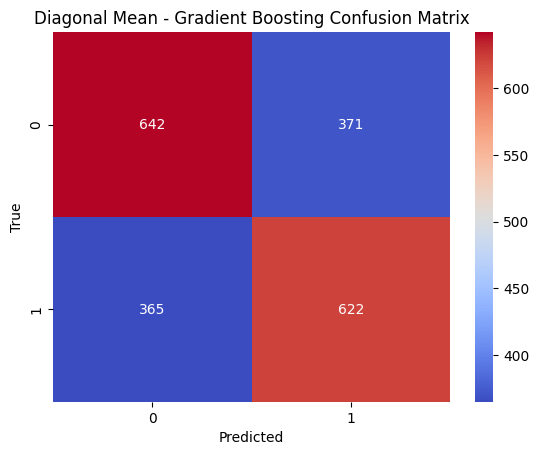


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.6965
              precision    recall  f1-score   support

         0.0     0.6944    0.7157    0.7049      1013
         1.0     0.6987    0.6768    0.6876       987

    accuracy                         0.6965      2000
   macro avg     0.6966    0.6962    0.6963      2000
weighted avg     0.6966    0.6965    0.6964      2000



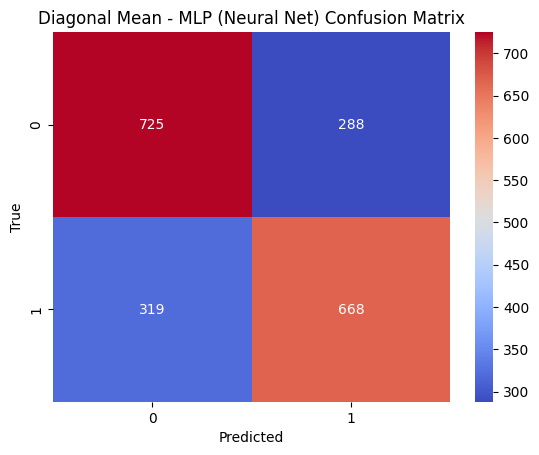


=== 🔍 Feature Set: Rich Stats ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.6825
              precision    recall  f1-score   support

         0.0     0.6936    0.6683    0.6807      1013
         1.0     0.6719    0.6971    0.6842       987

    accuracy                         0.6825      2000
   macro avg     0.6828    0.6827    0.6825      2000
weighted avg     0.6829    0.6825    0.6825      2000



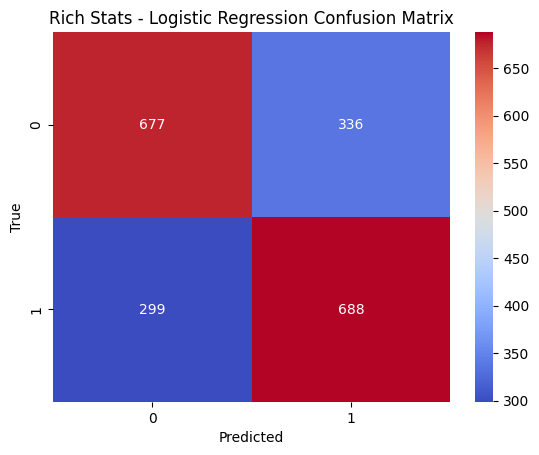


🚀 Model: SVC
✅ Accuracy: 0.6585
              precision    recall  f1-score   support

         0.0     0.6744    0.6298    0.6514      1013
         1.0     0.6442    0.6879    0.6654       987

    accuracy                         0.6585      2000
   macro avg     0.6593    0.6589    0.6584      2000
weighted avg     0.6595    0.6585    0.6583      2000



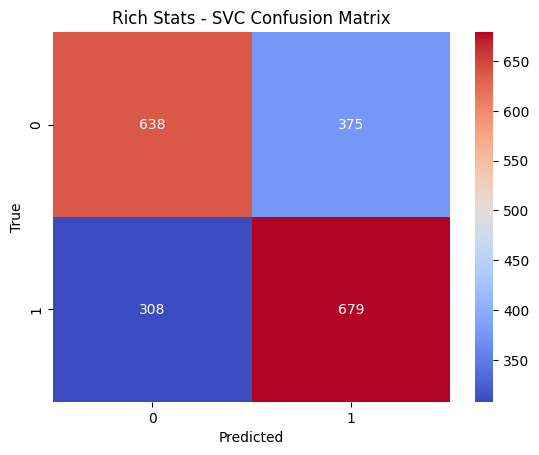


🚀 Model: KNN
✅ Accuracy: 0.5715
              precision    recall  f1-score   support

         0.0     0.5802    0.5568    0.5683      1013
         1.0     0.5632    0.5866    0.5747       987

    accuracy                         0.5715      2000
   macro avg     0.5717    0.5717    0.5715      2000
weighted avg     0.5718    0.5715    0.5714      2000



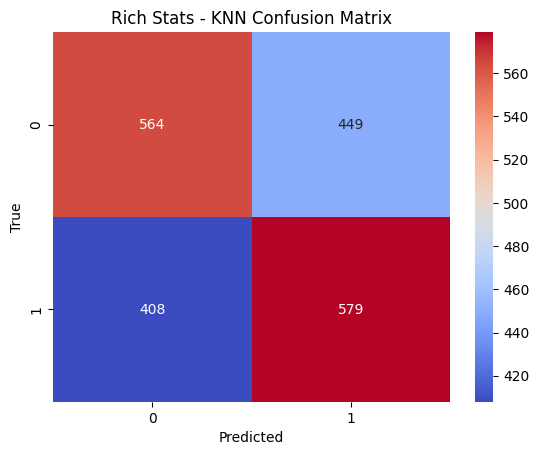


🚀 Model: Random Forest
✅ Accuracy: 0.6985
              precision    recall  f1-score   support

         0.0     0.6975    0.7147    0.7060      1013
         1.0     0.6996    0.6819    0.6906       987

    accuracy                         0.6985      2000
   macro avg     0.6985    0.6983    0.6983      2000
weighted avg     0.6985    0.6985    0.6984      2000



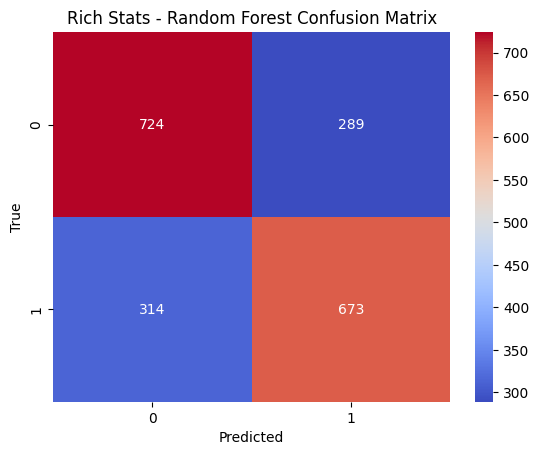


🚀 Model: Gradient Boosting
✅ Accuracy: 0.6910
              precision    recall  f1-score   support

         0.0     0.6927    0.7009    0.6968      1013
         1.0     0.6892    0.6809    0.6850       987

    accuracy                         0.6910      2000
   macro avg     0.6910    0.6909    0.6909      2000
weighted avg     0.6910    0.6910    0.6910      2000



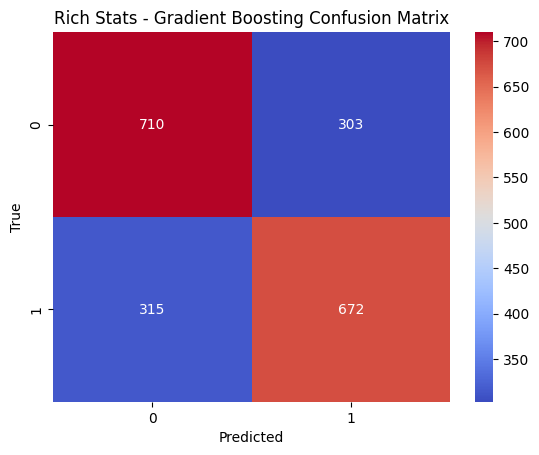


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.6700
              precision    recall  f1-score   support

         0.0     0.7662    0.5015    0.6062      1013
         1.0     0.6223    0.8430    0.7160       987

    accuracy                         0.6700      2000
   macro avg     0.6943    0.6722    0.6611      2000
weighted avg     0.6952    0.6700    0.6604      2000



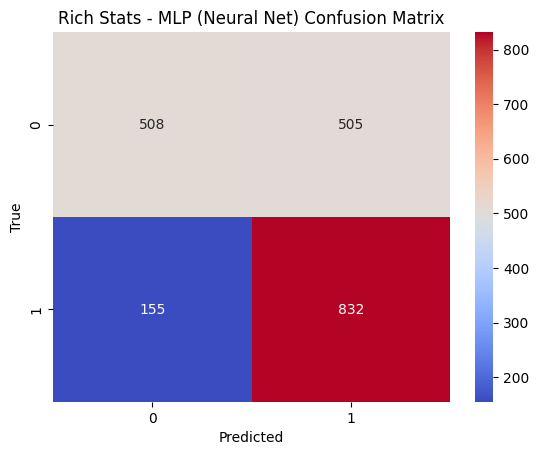


=== 🔍 Feature Set: [CLS] Focus ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



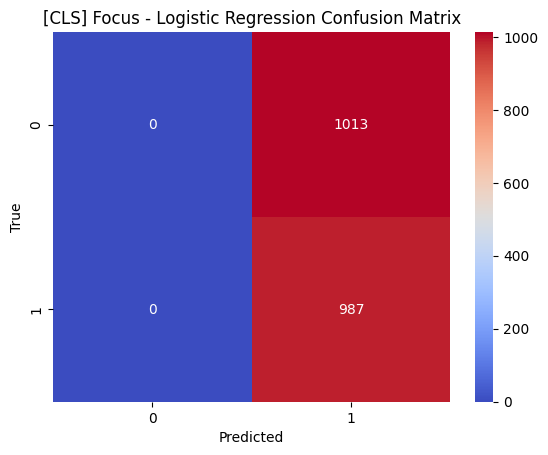


🚀 Model: SVC
✅ Accuracy: 0.4955
              precision    recall  f1-score   support

         0.0     0.5078    0.1283    0.2049      1013
         1.0     0.4937    0.8723    0.6305       987

    accuracy                         0.4955      2000
   macro avg     0.5008    0.5003    0.4177      2000
weighted avg     0.5008    0.4955    0.4149      2000



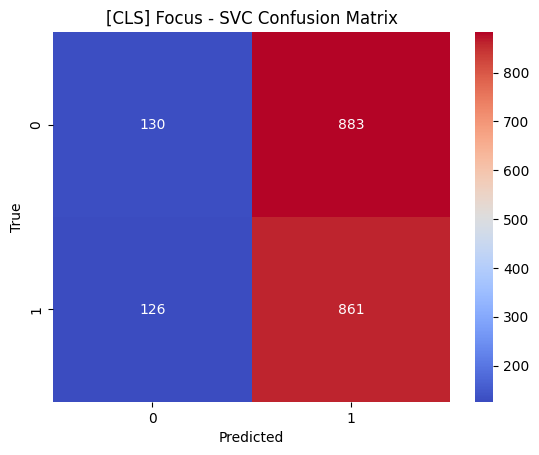


🚀 Model: KNN
✅ Accuracy: 0.5000
              precision    recall  f1-score   support

         0.0     0.5036    0.9003    0.6459      1013
         1.0     0.4656    0.0892    0.1497       987

    accuracy                         0.5000      2000
   macro avg     0.4846    0.4947    0.3978      2000
weighted avg     0.4848    0.5000    0.4010      2000



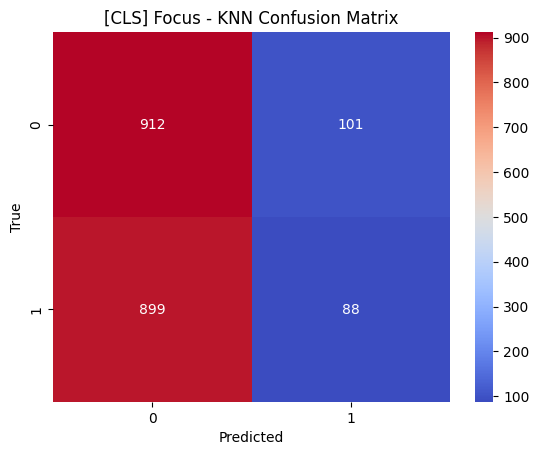


🚀 Model: Random Forest
✅ Accuracy: 0.5130
              precision    recall  f1-score   support

         0.0     0.5186    0.5360    0.5272      1013
         1.0     0.5068    0.4894    0.4979       987

    accuracy                         0.5130      2000
   macro avg     0.5127    0.5127    0.5126      2000
weighted avg     0.5128    0.5130    0.5128      2000



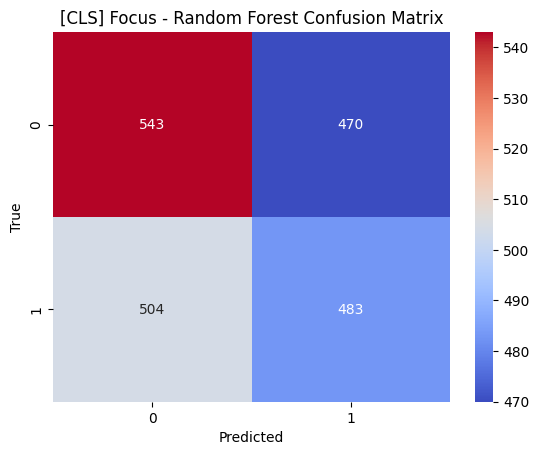


🚀 Model: Gradient Boosting
✅ Accuracy: 0.4960
              precision    recall  f1-score   support

         0.0     0.5025    0.4867    0.4945      1013
         1.0     0.4897    0.5056    0.4975       987

    accuracy                         0.4960      2000
   macro avg     0.4961    0.4961    0.4960      2000
weighted avg     0.4962    0.4960    0.4960      2000



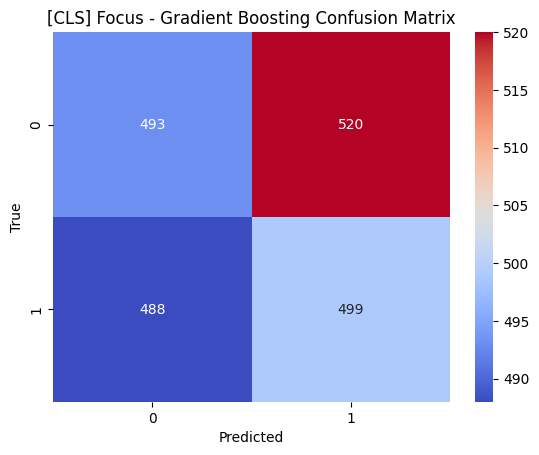


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



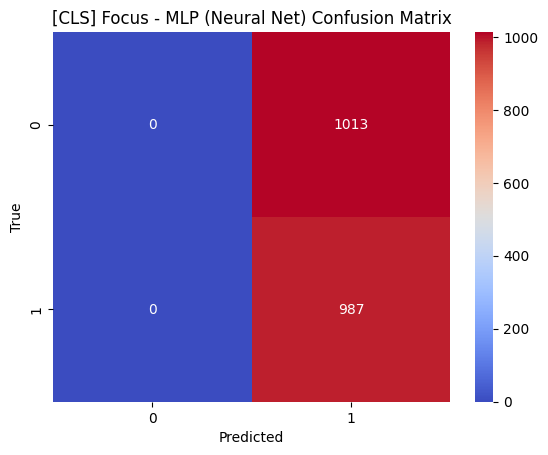

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "MLP (Neural Net)": MLPClassifier(max_iter=500)
}

for feat_name, X in feature_sets.items():
    print(f"\n=== 🔍 Feature Set: {feat_name} ===")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for model_name, model in models.items():
        print(f"\n🚀 Model: {model_name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"✅ Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, digits=4))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
        plt.title(f"{feat_name} - {model_name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()


### Accuracy overview (BERT)

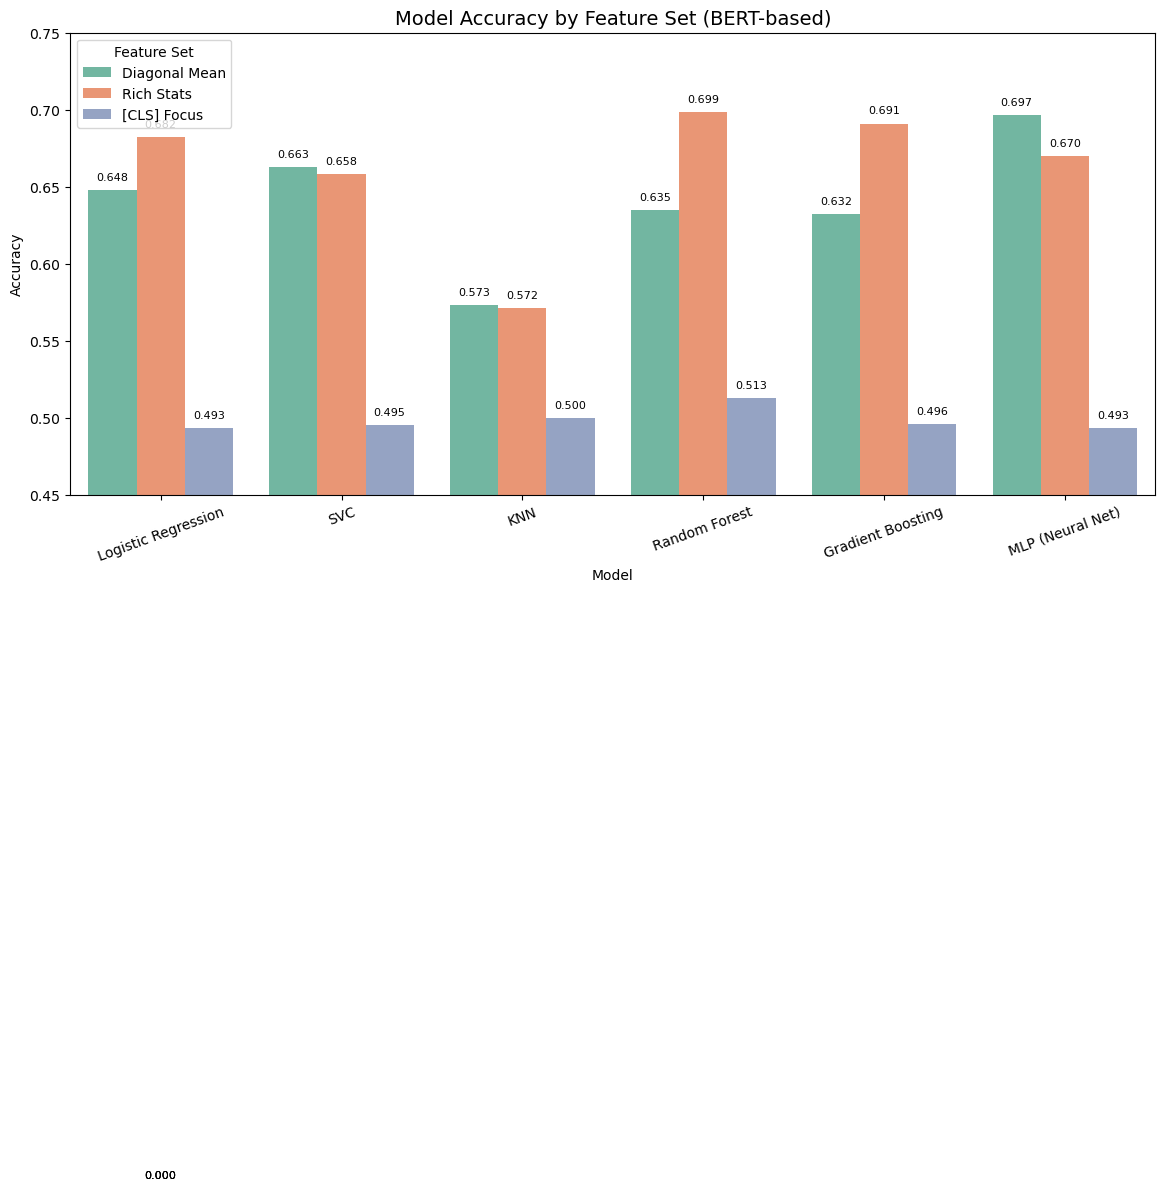

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Organize data
data = {
    "Feature Set": ["Diagonal Mean"] * 6 + ["Rich Stats"] * 6 + ["[CLS] Focus"] * 6,
    "Model": ["Logistic Regression", "SVC", "KNN", "Random Forest", "Gradient Boosting", "MLP (Neural Net)"] * 3,
    "Accuracy": [
        0.6480, 0.6630, 0.5730, 0.6350, 0.6320, 0.6965,
        0.6825, 0.6585, 0.5715, 0.6985, 0.6910, 0.6700,
        0.4935, 0.4955, 0.5000, 0.5130, 0.4960, 0.4935
    ]
}

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df, x="Model", y="Accuracy", hue="Feature Set", palette="Set2")

# Write accuracy values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 0.005,
        s=f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Model Accuracy by Feature Set (BERT-based)", fontsize=14)
plt.xticks(rotation=20)
plt.ylim(0.45, 0.75)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

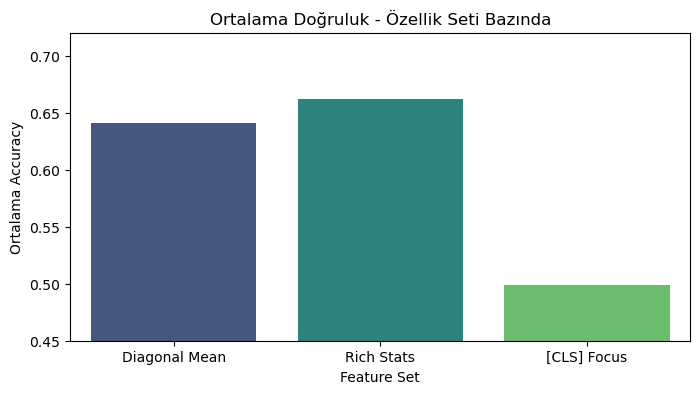

In [5]:
# Compute average accuracies
avg_acc = df.groupby("Feature Set")["Accuracy"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_acc, x="Feature Set", y="Accuracy", palette="viridis")
plt.title("Ortalama Doğruluk - Özellik Seti Bazında")
plt.ylim(0.45, 0.72)
plt.ylabel("Ortalama Accuracy")
plt.show()

## 7. Turkish-Gemma-9B · Attention features
The same three feature sets, extracted from a 9B-parameter decoder model.

In [21]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name2 = "ytu-ce-cosmos/Turkish-Gemma-9b-v0.1"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)
# model2 = AutoModelForCausalLM.from_pretrained(model_name2)
model2 = AutoModelForCausalLM.from_pretrained(model_name2, output_attentions=True)
model2.eval()


Gemma2ForCausalLM(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 3584, padding_idx=0)
    (layers): ModuleList(
      (0-41): 42 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=3584, out_features=4096, bias=False)
          (k_proj): Linear(in_features=3584, out_features=2048, bias=False)
          (v_proj): Linear(in_features=3584, out_features=2048, bias=False)
          (o_proj): Linear(in_features=4096, out_features=3584, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=3584, out_features=14336, bias=False)
          (up_proj): Linear(in_features=3584, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=3584, bias=False)
          (act_fn): PytorchGELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((3584,), eps=1e-06)
        (pre_feedforward_layernorm): G

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)
print(f"Using device: {device}")

Using device: cuda


In [23]:
def extract_attention_features_gemma(text, max_length=128, verbose=False):
    inputs = tokenizer2(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model2(**inputs)
    attentions = outputs.attentions  # (layers, batch, heads, from, to)

    features = []
    for layer_idx, layer_attention in enumerate(attentions):
        layer_attention = layer_attention[0]  # remove batch dim (batch size = 1)
        for head_idx, head_attention in enumerate(layer_attention):
            diag = torch.diagonal(head_attention, dim1=-2, dim2=-1)
            mean_val = diag.mean().item()
            features.append(mean_val)
            if verbose and layer_idx == 0:
                print(f"Layer {layer_idx}, Head {head_idx}: {mean_val:.4f}")
    return features

# Read data from CSV
df = pd.read_csv("../data/balanced_movie_reviews.csv")
comments = df["comment"].tolist()
labels = df["class"].tolist()

# Feature extraction (tqdm progress bar)
X_gemma = [extract_attention_features_gemma(comment) for comment in tqdm(comments)]
y = labels

# Save
np.save("X_attention_features_gemma.npy", X_gemma)
# np.save("y_labels.npy", y)


In [24]:
# 📌 Rich attention feature extractor
def extract_rich_attention_features_gemma(text, max_length=128, verbose=False):
    inputs = tokenizer2(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model2(**inputs)
    attentions = outputs.attentions  # (layer, batch, head, from, to)

    features = []
    for layer_idx, layer_attention in enumerate(attentions):
        layer_attention = layer_attention[0]  # remove batch dim
        for head_idx, head_attention in enumerate(layer_attention):
            diag = torch.diagonal(head_attention, dim1=-2, dim2=-1)
            diag_mean = diag.mean().item()
            mean_all = head_attention.mean().item()
            max_all = head_attention.max().item()
            std_all = head_attention.std().item()
            features.extend([diag_mean, mean_all, max_all, std_all])

            if verbose and layer_idx == 0:
                print(f"[{layer_idx}:{head_idx}] diag={diag_mean:.4f}, mean={mean_all:.4f}, max={max_all:.4f}, std={std_all:.4f}")
    return features

# 📌 First-token attention extractor (no [CLS] in GPT-style models, so the first token is used)
def extract_first_token_attention_gemma(text, max_length=128, verbose=False):
    inputs = tokenizer2(text, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model2(**inputs)
    attentions = outputs.attentions

    features = []
    for layer_idx, layer_attention in enumerate(attentions):
        layer_attention = layer_attention[0]  # remove batch dim
        for head_idx, head_attention in enumerate(layer_attention):
            first_token_attention = head_attention[0]  # focus on token 0
            mean_attention = first_token_attention.mean().item()
            features.append(mean_attention)
            if verbose and layer_idx == 0:
                print(f"[{layer_idx}:{head_idx}] first token mean attention = {mean_attention:.4f}")
    return features

In [25]:
# 🔽 Load data
df = pd.read_csv("../data/balanced_movie_reviews.csv")
comments = df["comment"].tolist()
labels = df["class"].tolist()

# 🎯 Rich attention
X_rich_gemma = [extract_rich_attention_features_gemma(c) for c in tqdm(comments)]
np.save("X_attention_features_rich_gemma.npy", X_rich_gemma)

# 🎯 First token attention
X_cls_gemma = [extract_first_token_attention_gemma(c) for c in tqdm(comments)]
np.save("X_cls_attention_features_gemma.npy", X_cls_gemma)

print("✅ Gemma attention features extracted and saved.")

✅ Gemma attention features extracted and saved.


### Comparison of Gemma feature sets


=== 🔍 Feature Set: Diagonal Mean (GEMMA) ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.7750
              precision    recall  f1-score   support

         0.0     0.7790    0.7759    0.7774      1013
         1.0     0.7709    0.7741    0.7725       987

    accuracy                         0.7750      2000
   macro avg     0.7750    0.7750    0.7750      2000
weighted avg     0.7750    0.7750    0.7750      2000



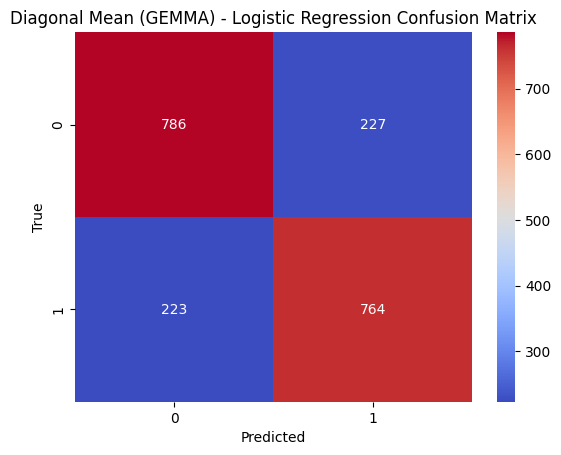


🚀 Model: SVC
✅ Accuracy: 0.7025
              precision    recall  f1-score   support

         0.0     0.6883    0.7542    0.7197      1013
         1.0     0.7202    0.6494    0.6830       987

    accuracy                         0.7025      2000
   macro avg     0.7043    0.7018    0.7014      2000
weighted avg     0.7040    0.7025    0.7016      2000



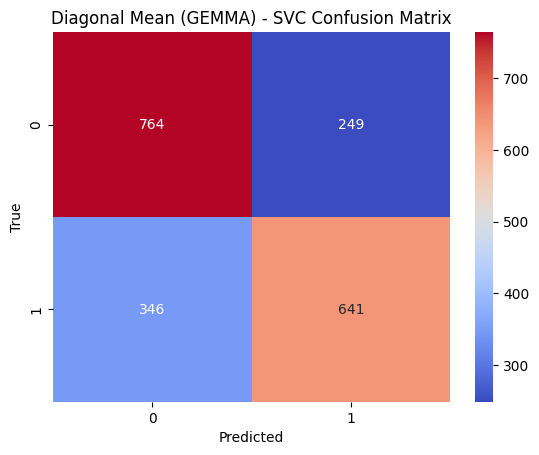


🚀 Model: KNN
✅ Accuracy: 0.6365
              precision    recall  f1-score   support

         0.0     0.6421    0.6377    0.6399      1013
         1.0     0.6308    0.6353    0.6330       987

    accuracy                         0.6365      2000
   macro avg     0.6365    0.6365    0.6365      2000
weighted avg     0.6365    0.6365    0.6365      2000



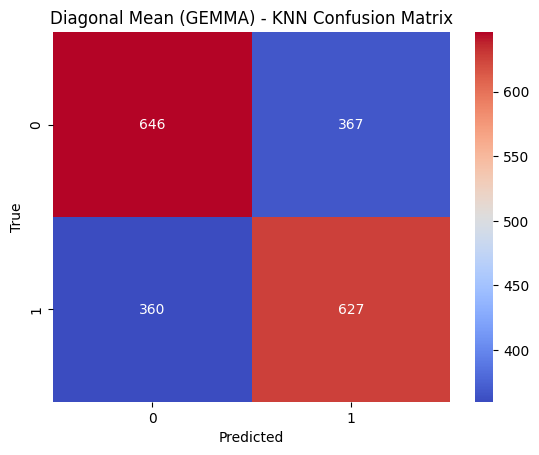


🚀 Model: Random Forest
✅ Accuracy: 0.7055
              precision    recall  f1-score   support

         0.0     0.6949    0.7463    0.7197      1013
         1.0     0.7182    0.6636    0.6898       987

    accuracy                         0.7055      2000
   macro avg     0.7065    0.7050    0.7047      2000
weighted avg     0.7064    0.7055    0.7049      2000



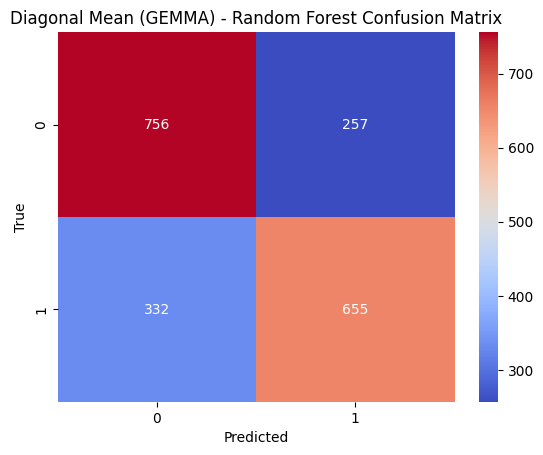


🚀 Model: Gradient Boosting
✅ Accuracy: 0.7400
              precision    recall  f1-score   support

         0.0     0.7570    0.7167    0.7363      1013
         1.0     0.7243    0.7639    0.7436       987

    accuracy                         0.7400      2000
   macro avg     0.7407    0.7403    0.7399      2000
weighted avg     0.7409    0.7400    0.7399      2000



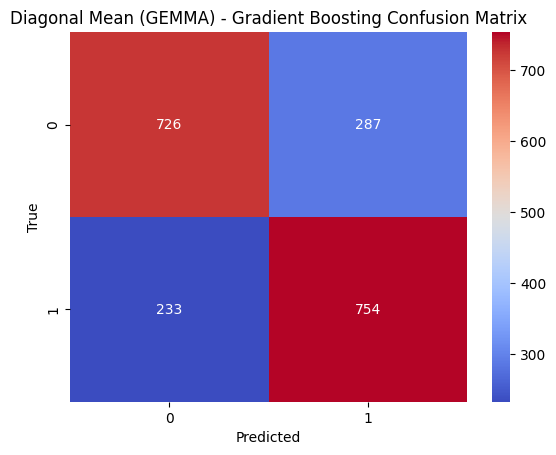


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.8045
              precision    recall  f1-score   support

         0.0     0.7962    0.8253    0.8105      1013
         1.0     0.8137    0.7832    0.7981       987

    accuracy                         0.8045      2000
   macro avg     0.8049    0.8042    0.8043      2000
weighted avg     0.8048    0.8045    0.8044      2000



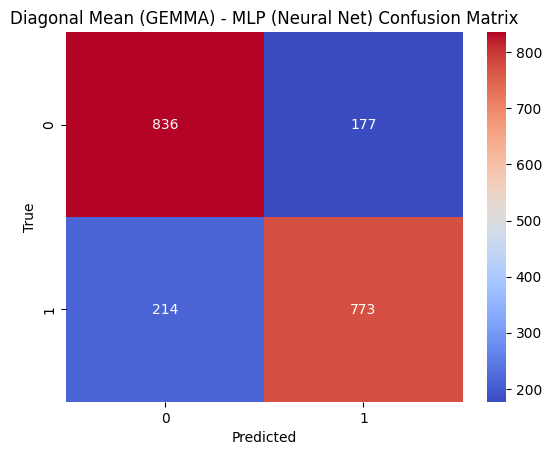


=== 🔍 Feature Set: Rich Stats (GEMMA) ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.7855
              precision    recall  f1-score   support

         0.0     0.7903    0.7848    0.7875      1013
         1.0     0.7807    0.7862    0.7834       987

    accuracy                         0.7855      2000
   macro avg     0.7855    0.7855    0.7855      2000
weighted avg     0.7855    0.7855    0.7855      2000



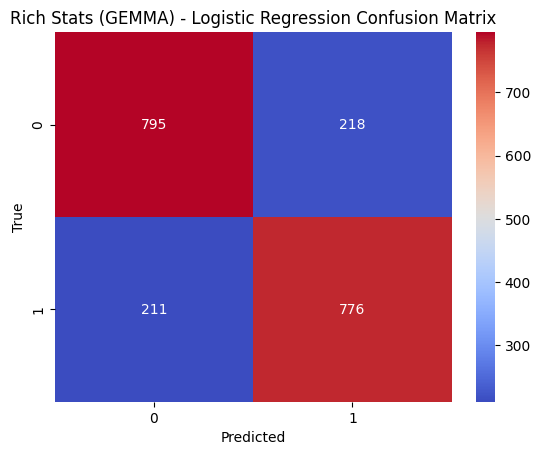


🚀 Model: SVC
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



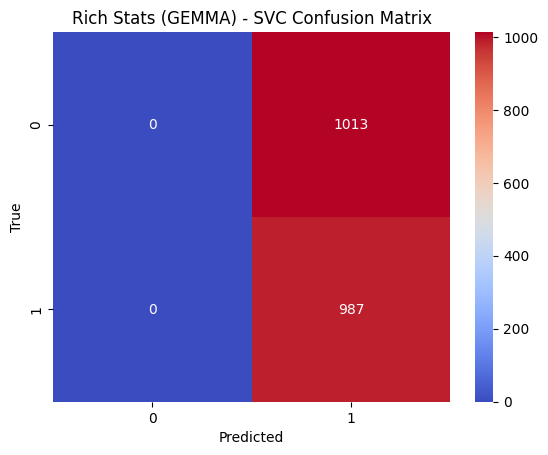


🚀 Model: KNN
✅ Accuracy: 0.6295
              precision    recall  f1-score   support

         0.0     0.6402    0.6130    0.6263      1013
         1.0     0.6194    0.6464    0.6326       987

    accuracy                         0.6295      2000
   macro avg     0.6298    0.6297    0.6295      2000
weighted avg     0.6299    0.6295    0.6294      2000



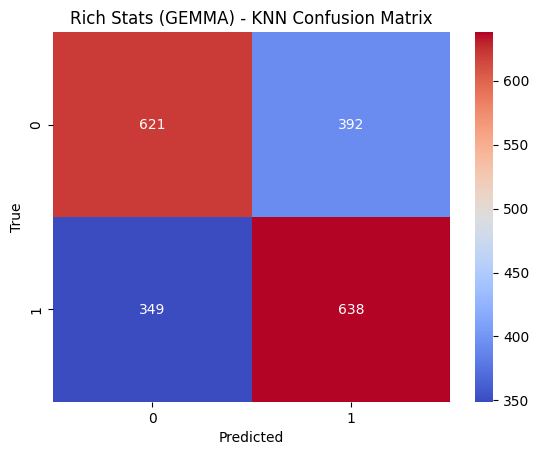


🚀 Model: Random Forest
✅ Accuracy: 0.7250
              precision    recall  f1-score   support

         0.0     0.7232    0.7404    0.7317      1013
         1.0     0.7269    0.7092    0.7179       987

    accuracy                         0.7250      2000
   macro avg     0.7251    0.7248    0.7248      2000
weighted avg     0.7250    0.7250    0.7249      2000



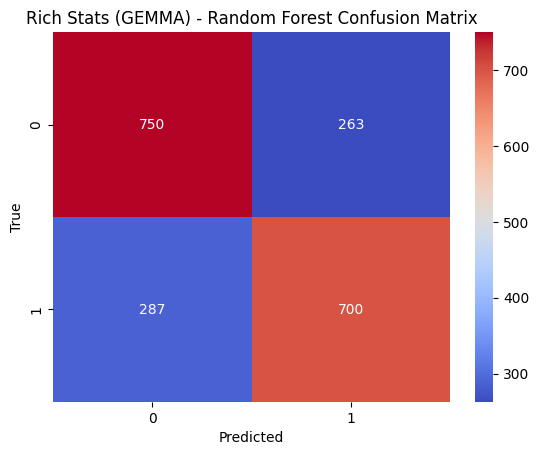


🚀 Model: Gradient Boosting
✅ Accuracy: 0.7515
              precision    recall  f1-score   support

         0.0     0.7643    0.7364    0.7501      1013
         1.0     0.7393    0.7670    0.7529       987

    accuracy                         0.7515      2000
   macro avg     0.7518    0.7517    0.7515      2000
weighted avg     0.7520    0.7515    0.7515      2000



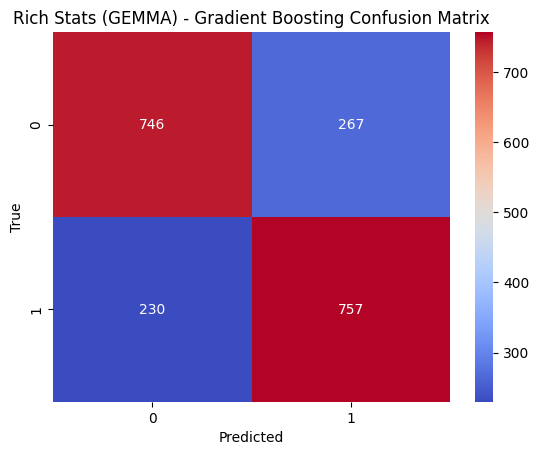


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.6590
              precision    recall  f1-score   support

         0.0     0.6073    0.9250    0.7332      1013
         1.0     0.8337    0.3860    0.5277       987

    accuracy                         0.6590      2000
   macro avg     0.7205    0.6555    0.6304      2000
weighted avg     0.7190    0.6590    0.6318      2000



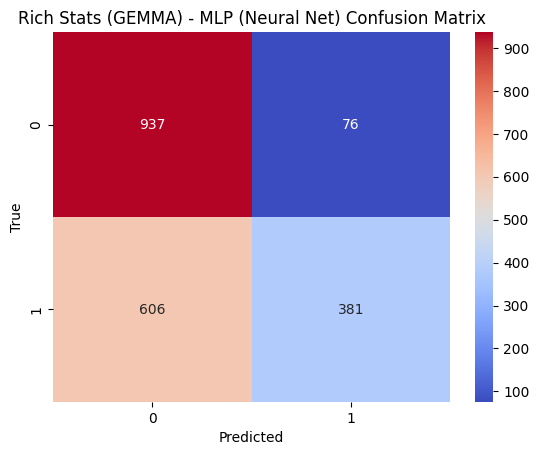


=== 🔍 Feature Set: First Token Attention (GEMMA) ===

🚀 Model: Logistic Regression
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



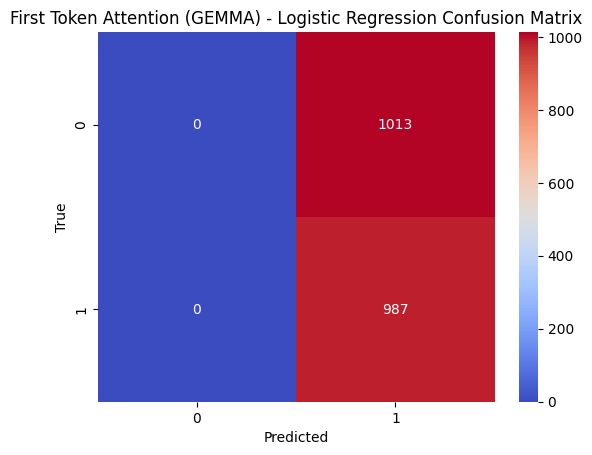


🚀 Model: SVC
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



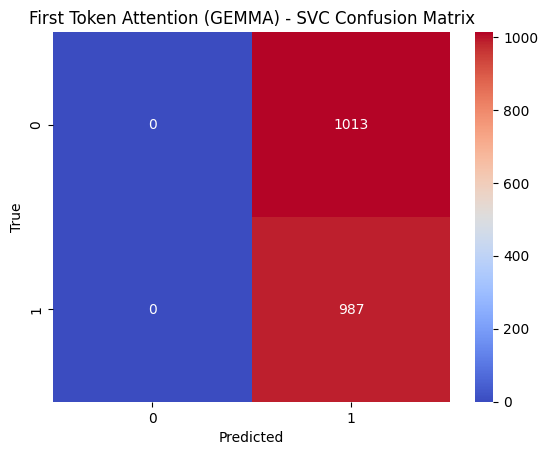


🚀 Model: KNN
✅ Accuracy: 0.5065
              precision    recall  f1-score   support

         0.0     0.5065    1.0000    0.6724      1013
         1.0     0.0000    0.0000    0.0000       987

    accuracy                         0.5065      2000
   macro avg     0.2532    0.5000    0.3362      2000
weighted avg     0.2565    0.5065    0.3406      2000



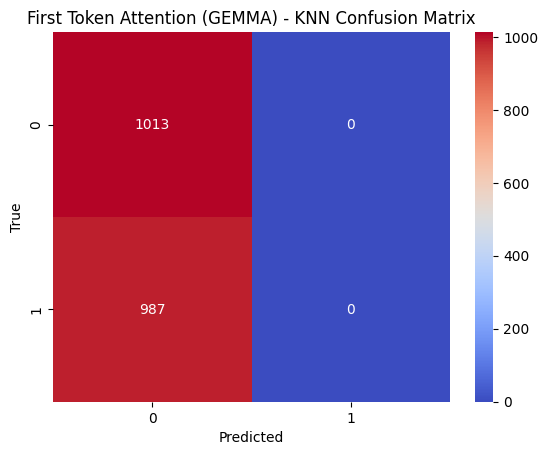


🚀 Model: Random Forest
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



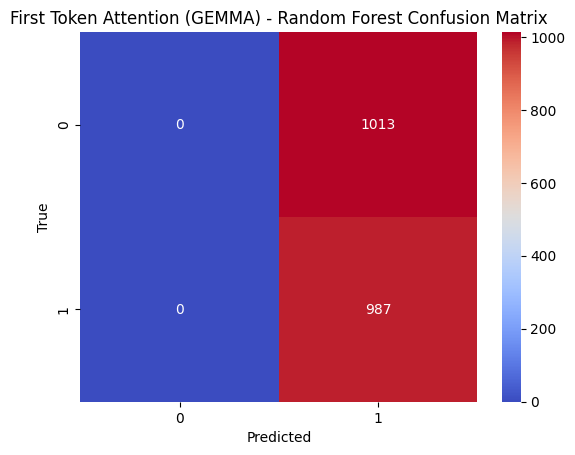


🚀 Model: Gradient Boosting
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



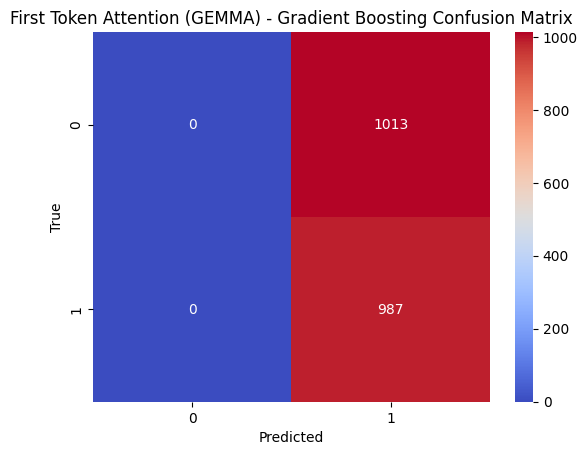


🚀 Model: MLP (Neural Net)
✅ Accuracy: 0.4935
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      1013
         1.0     0.4935    1.0000    0.6609       987

    accuracy                         0.4935      2000
   macro avg     0.2467    0.5000    0.3304      2000
weighted avg     0.2435    0.4935    0.3261      2000



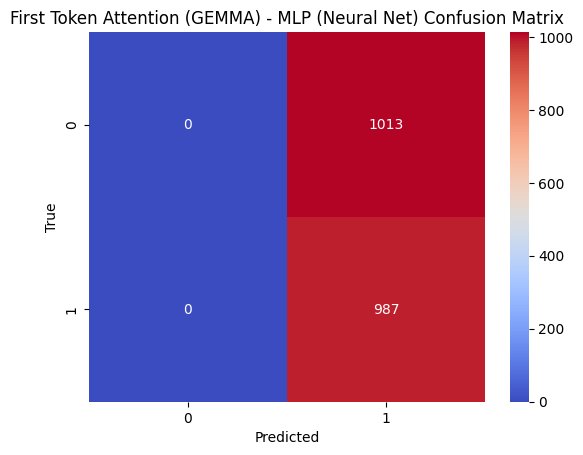

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the features
X_diag = np.load("X_attention_features_gemma.npy")
X_rich = np.load("X_attention_features_rich_gemma.npy")
X_first = np.load("X_cls_attention_features_gemma.npy") 
y = np.load("y_labels.npy")

# 2. Feature sets
feature_sets = {
    "Diagonal Mean (GEMMA)": X_diag,
    "Rich Stats (GEMMA)": X_rich,
    "First Token Attention (GEMMA)": X_first
}

# 3. Modeller
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "MLP (Neural Net)": MLPClassifier(max_iter=500)
}

# 4. Training and evaluation
for feat_name, X in feature_sets.items():
    print(f"\n=== 🔍 Feature Set: {feat_name} ===")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for model_name, model in models.items():
        print(f"\n🚀 Model: {model_name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"✅ Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, digits=4))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
        plt.title(f"{feat_name} - {model_name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()


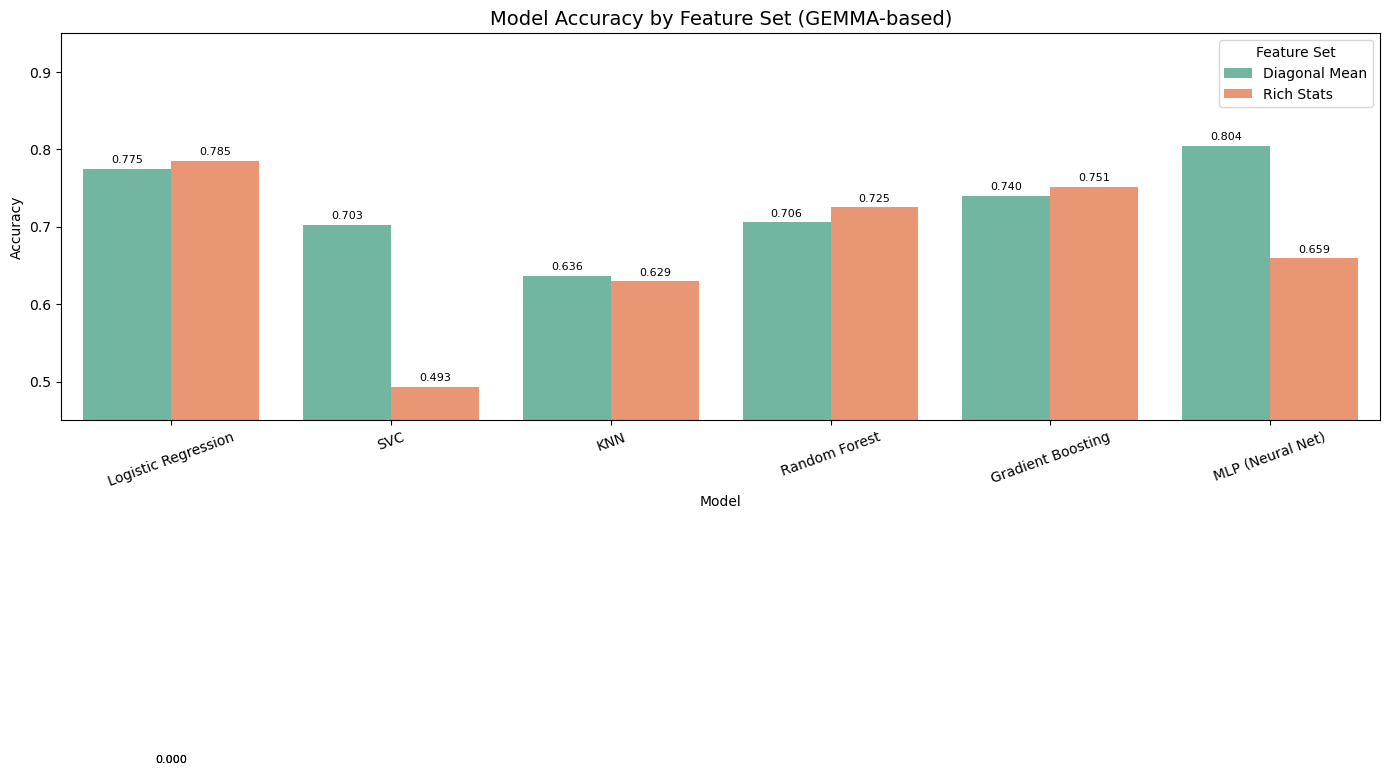

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# GEMMA data
data_gemma = {
    "Feature Set": ["Diagonal Mean"] * 6 + ["Rich Stats"] * 6,
    "Model": ["Logistic Regression", "SVC", "KNN", "Random Forest", "Gradient Boosting", "MLP (Neural Net)"] * 2,
    "Accuracy": [
        0.7750, 0.7025, 0.6365, 0.7055, 0.7400, 0.8045,
        0.7855, 0.4935, 0.6295, 0.7250, 0.7515, 0.6590
    ]
}

df_gemma = pd.DataFrame(data_gemma)

# Plot
plt.figure(figsize=(14, 14))
ax = sns.barplot(data=df_gemma, x="Model", y="Accuracy", hue="Feature Set", palette="Set2")

# Write accuracy values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 0.005,
        s=f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Model Accuracy by Feature Set (GEMMA-based)", fontsize=14)
plt.xticks(rotation=20)
plt.ylim(0.45, 0.95)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

## Summary

- **Gemma-9B attention features clearly outperform BERT**: best accuracy **80.5%** (diagonal mean + MLP) vs. **69.8%** for BERT (rich statistics + Random Forest).
- The simple **diagonal-mean** feature ("self-attention strength") carries most of the signal; adding mean/max/std helps BERT but not Gemma.
- **[CLS] / first-token features stay at chance level (~50%).** Each attention row is a softmax distribution that sums to 1, so the *mean* of a row is always `1 / seq_len`. With `padding="max_length"` every review has the same length, which makes the feature constant. For Gemma, the first token in a causal model can only attend to itself, so its row is constant as well. A useful follow-up would be to use the attention *distribution* (e.g. entropy, or the weights of the first row) instead of its mean.